# 07 — Prediction Model

**Evaluation: Extensibility** — Can we predict spot price and/or Germany flows from fundamentals? Model designed to work with more countries, data sources, or live feeds.

We build a simple but extensible model: features from load, generation mix, weather, and flows → predict DE spot price.

In [3]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from src.data_loader import (
    load_spot_price,
    load_total_load,
    load_generation_pivot,
    load_weather,
    load_flows_into,
)

## Feature engineering

In [4]:
def _to_15min(df: pd.DataFrame) -> pd.DataFrame:
    """Expand hourly/mixed data to 15-min with ffill."""
    full_idx = pd.date_range(df.index.min(), df.index.max(), freq="15min", tz="UTC")
    return df.reindex(full_idx).ffill()


def build_features(zone: str = "DE") -> pd.DataFrame:
    """Build 15-min feature matrix for prediction. Extensible to more zones/sources."""
    load = load_total_load(zone)  # already 15-min
    gen = load_generation_pivot(zone)  # already 15-min
    weather = _to_15min(load_weather(zone))
    flows = load_flows_into(zone)
    pivot_flows = flows.pivot(index="time", columns="zone", values="value (MW)")
    pivot_flows.index = pd.to_datetime(pivot_flows.index, utc=True)
    pivot_flows = _to_15min(pivot_flows)

    # Renewable share
    ren = ["SOLAR", "WIND-ONSHORE", "WIND-OFFSHORE", "HYDRO-ROR", "HYDRO-WATER-RESERVOIR", "BIOMASS"]
    ren_cols = [c for c in ren if c in gen.columns]
    total_gen = gen.sum(axis=1)
    renewable = gen[ren_cols].sum(axis=1) if ren_cols else pd.Series(0, index=gen.index)
    gen["renewable_share"] = renewable / total_gen.replace(0, np.nan)

    # Net import
    net_import = pivot_flows.sum(axis=1).to_frame("net_import") if not pivot_flows.empty else pd.DataFrame()

    # Time features (use load index as 15-min base)
    idx = load.index
    features = pd.DataFrame(index=idx)
    features["hour"] = idx.hour
    features["dayofweek"] = idx.dayofweek
    features["month"] = idx.month

    # Join (reindex to idx for alignment)
    for name, df in [("load", load), ("renewable_share", gen[["renewable_share"]]), ("net_import", net_import)]:
        if not df.empty:
            features = features.join(df.reindex(idx).ffill(), how="left")
    features = features.join(weather.reindex(idx).ffill(), how="left")
    features = features.dropna(how="all", axis=1)
    return features

X = build_features("DE")
sp = load_spot_price("DE")
y = _to_15min(sp)["price"].reindex(X.index).ffill()
valid = X.notna().all(axis=1) & y.notna()
X, y = X[valid].dropna(), y[valid].squeeze()
print("Features:", list(X.columns))
print(f"Samples: {len(X)}")

Features: ['hour', 'dayofweek', 'month', 'load', 'renewable_share', 'net_import', 'temperature', 'wind_speed_10m', 'wind_speed_100m', 'humidity', 'cloud_cover', 'wind_direction_10m', 'wind_direction_100m', 'precipitation']
Samples: 70176


## Train and evaluate

In [5]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f} EUR/MWh")
print(f"R²: {r2_score(y_test, y_pred):.3f}")

# Feature importance
imp = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nFeature importance:")
print(imp.head(10))

MAE: 19.04 EUR/MWh
R²: 0.578

Feature importance:
renewable_share        0.707906
load                   0.131526
month                  0.031948
net_import             0.023874
temperature            0.023707
wind_direction_10m     0.019595
hour                   0.014959
wind_direction_100m    0.009356
humidity               0.009190
wind_speed_100m        0.008790
dtype: float64


## Sample prediction plot

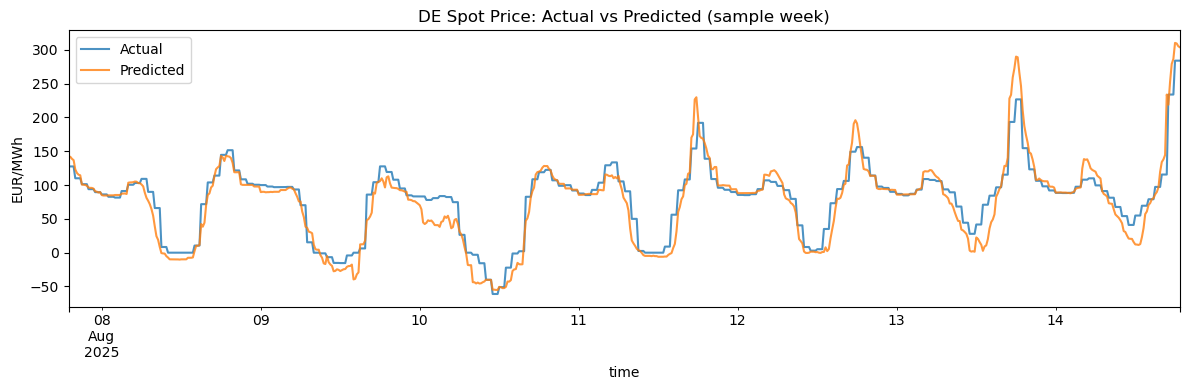

In [6]:
import matplotlib.pyplot as plt

sample_idx = X_test.index[:672]  # 1 week (672 × 15min)
X_sample = X_test.loc[sample_idx].dropna()
y_true_s = y_test.loc[X_sample.index]
y_pred_s = pd.Series(model.predict(X_sample), index=X_sample.index)

plt.figure(figsize=(12, 4))
y_true_s.plot(label="Actual", alpha=0.8)
y_pred_s.plot(label="Predicted", alpha=0.8)
plt.ylabel("EUR/MWh")
plt.title("DE Spot Price: Actual vs Predicted (sample week)")
plt.legend()
plt.tight_layout()
plt.show()